# Time Series Forecasting of Stock Market Data with ARIMA in Python

# 1. Time Series Data
Time series data is a type of data that is collected over time at regular intervals. It is a sequence of data points that are ordered chronologically and can be used to analyze trends, patterns, and behaviors over time. Time series data can be collected from a variety of sources, such as sensors, financial markets, weather stations, and social media platforms.

Examples of time series data include stock prices, temperature readings, website traffic, and sales data. Time series data can be analyzed using various statistical and machine learning techniques, such as regression analysis, ARIMA models, and deep learning models.

Time series data is often used in forecasting and prediction applications, where the goal is to predict future values based on past observations. Time series analysis can also be used to identify anomalies, trends, and seasonality in the data, which can provide insights into the underlying processes that generate the data.

Overall, time series data is an important type of data that is used in many different fields, including finance, economics, engineering, and social sciences.

- Time series data is a sequence of data points collected over time that can be used to analyze trends and patterns. It can be collected from various sources and analyzed using statistical and machine learning techniques.
- Time series forecasting is the process of predicting future values based on past observations. Time series data is used in many different fields, including finance, economics, engineering, and social sciences.

# Stock Market Data scraping in Python

In [76]:
# imporot libraries
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import yfinance as yf
import datetime as dt
from datetime import date, timedelta
import plotly.graph_objects as go
import plotly.express as px

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [77]:
date.today()

datetime.date(2026, 8, 22)

In [78]:
# define the dates to fetch data
today = date.today()
d1 = today.strftime("%Y-%m-%d")
end_date = d1
d2 = date.today() - timedelta(days=365)
d2 = d2.strftime("%Y-%m-%d")
start_date = d2
print("Your data will be between these dates: ", start_date, end_date)

Your data will be between these dates:  2025-08-22 2026-08-22


In [79]:
# deifne the ticker
ticker = 'GOOGL'

df = yf.download(ticker, start=start_date, end=end_date, progress=False)
df.head()

Price,Close,High,Low,Open,Volume
Ticker,GOOGL,GOOGL,GOOGL,GOOGL,GOOGL
Date,,,,,
2025-08-22,205.503738,207.946766,200.727371,202.153296,42827000
2025-08-25,207.896912,209.921136,204.696036,205.842759,29928900
2025-08-26,206.550751,207.258738,205.114845,206.919693,28464100
2025-08-27,206.889786,208.315726,205.064990,205.114850,23022900
2025-08-28,211.037949,211.616301,206.311427,206.660437,32339300


In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 251 entries, 2025-08-22 to 2026-08-21
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   (Close, GOOGL)   251 non-null    float64
 1   (High, GOOGL)    251 non-null    float64
 2   (Low, GOOGL)     251 non-null    float64
 3   (Open, GOOGL)    251 non-null    float64
 4   (Volume, GOOGL)  251 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 11.8 KB


In [81]:
df.insert(0, "Date", df.index, True)
# df["Date"] = df.index
df.reset_index(drop=True, inplace=True)

In [82]:
df.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,GOOGL,GOOGL,GOOGL,GOOGL,GOOGL
0,2025-08-22,205.503738,207.946766,200.727371,202.153296,42827000
1,2025-08-25,207.896912,209.921136,204.696036,205.842759,29928900
2,2025-08-26,206.550751,207.258738,205.114845,206.919693,28464100
3,2025-08-27,206.889786,208.315726,205.064990,205.114850,23022900
4,2025-08-28,211.037949,211.616301,206.311427,206.660437,32339300


In [83]:
df.describe()

Price,Date,Close,High,Low,Open,Volume
Ticker,,GOOGL,GOOGL,GOOGL,GOOGL,GOOGL
count,251,251.000000,251.000000,251.000000,251.000000,2.510000e+02
mean,2026-02-20 21:02:09.083665408,314.756070,318.403263,310.438957,314.326767,3.336683e+07
min,2025-08-22 00:00:00,205.503738,207.258738,200.727371,202.153296,1.009740e+07
25%,2025-11-19 12:00:00,286.769211,291.185273,282.661912,287.272917,2.496165e+07
50%,2026-02-23 00:00:00,317.050629,320.892308,313.296984,317.079626,2.995930e+07
75%,2026-05-21 12:00:00,346.244995,350.885010,341.830002,346.554993,3.668550e+07
max,2026-08-21 00:00:00,402.379669,408.366081,396.123378,399.681282,1.147063e+08
std,NaN,46.048205,46.782493,45.357590,46.179708,1.430029e+07


In [84]:
# make a plot on plotly on x_axis = Date and y_axis = all other columns 

df.columns = [c[0] if isinstance(c, tuple) else c for c in df.columns]

fig = px.line(df, x='Date', y=df.columns[1:])
fig.show()

In [85]:
# select columns
df = df[['Date', 'Close']]
df.head()

,Date,Close
0,2025-08-22,205.503738
1,2025-08-25,207.896912
2,2025-08-26,206.550751
3,2025-08-27,206.889786
4,2025-08-28,211.037949


In [86]:
# plot the data to see how it looks like using plotly
# flatten multi-level columns if present
df.columns = [c[0] if isinstance(c, tuple) else c for c in df.columns]
fig = px.line(df, x='Date', y='Close', title='Google Stock Price')
fig.show()

In [87]:
# stationarity check on data
from statsmodels.tsa.stattools import adfuller
def adf_test(df):
    result = adfuller(df)
    print('ADF Statistic: %f' % result[0])
    print('p-value: %f' % result[1])
    if result[1] <= 0.05:
        print("Reject the null hypothesis. Data is stationary")
    else:
        print("Fail to reject the null hypothesis. Data is not stationary")

adf_test(df['Close'])

ADF Statistic: -1.963940
p-value: 0.302604
Fail to reject the null hypothesis. Data is not stationary


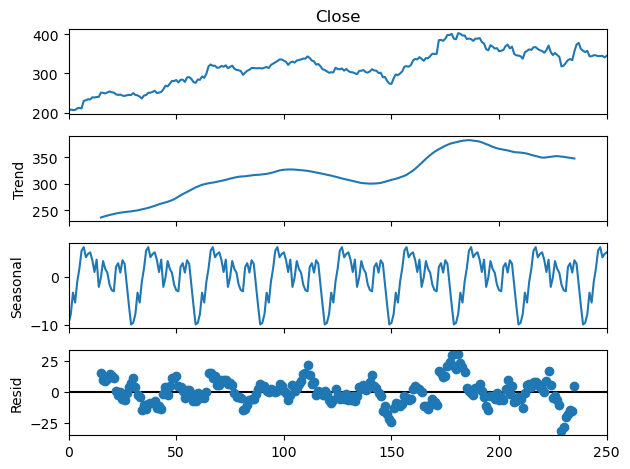

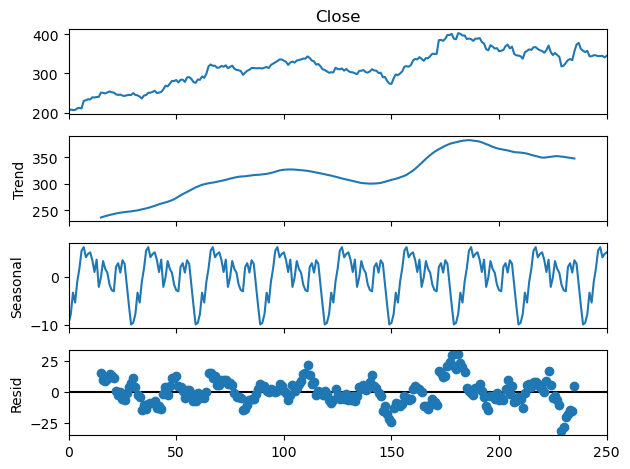

In [88]:
# decompose the data to see the trend, seasonality and noise
from statsmodels.tsa.seasonal import seasonal_decompose
decompose = seasonal_decompose(df['Close'], model='additive', period=30)
decompose.plot()

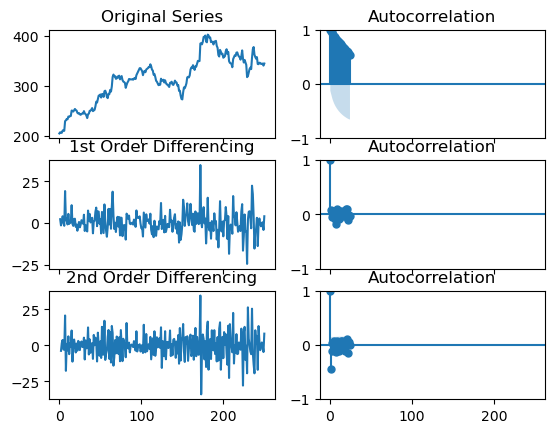

In [89]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Original Series
fig, axes = plt.subplots(3, 2, sharex=True)
axes[0, 0].plot(df['Close']); axes[0, 0].set_title('Original Series')
plot_acf(df['Close'], ax=axes[0, 1])

# 1st Differencing
axes[1, 0].plot(df['Close'].diff()); axes[1, 0].set_title('1st Order Differencing')
plot_acf(df['Close'].diff().dropna(), ax=axes[1, 1])

# 2nd Differencing
axes[2, 0].plot(df['Close'].diff().diff()); axes[2, 0].set_title('2nd Order Differencing')
plot_acf(df['Close'].diff().diff().dropna(), ax=axes[2, 1])

plt.show()

d = 1

# Lets find p value

           0
0   1.000000
1   0.977733
2   0.954545
3   0.931536
4   0.907773
5   0.883597
6   0.858308
7   0.834297
8   0.817989
9   0.802243
10  0.784213
11  0.764765
12  0.747648
13  0.730507
14  0.711464
15  0.692972
16  0.676705
17  0.661976
18  0.646523
19  0.630600
20  0.616051
21  0.599224
22  0.580336
23  0.560931


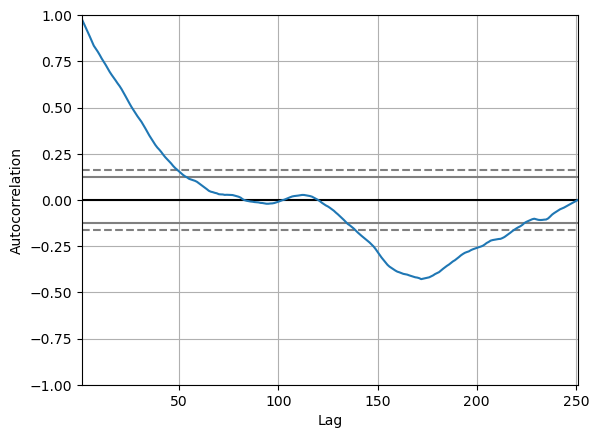

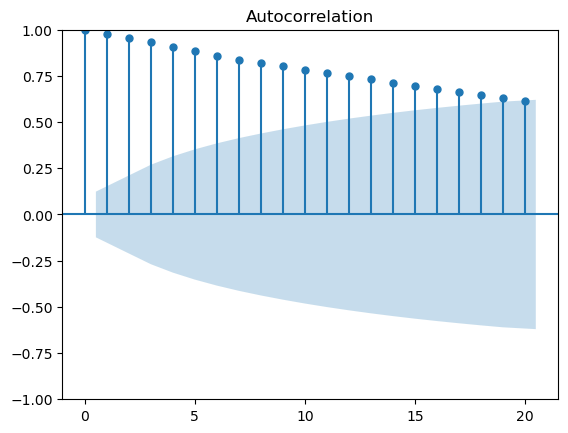

In [90]:
# plots
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
pd.plotting.autocorrelation_plot(df['Close'])

plot_acf(df['Close'], lags=20, alpha=0.05)

from statsmodels.tsa.stattools import acf, pacf
x_acf = pd.DataFrame(acf(df['Close']))
print(x_acf)

p = 2

# Lets find q value

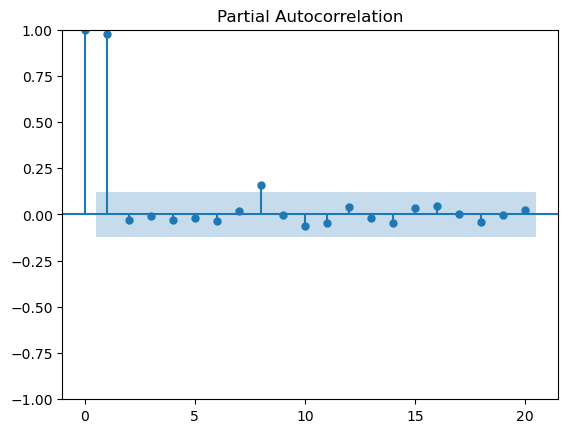

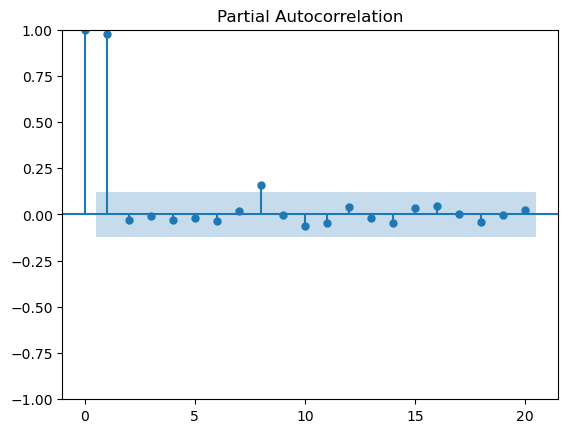

In [91]:
# partial autocorrelation
from statsmodels.tsa.stattools import acf, pacf
plot_pacf(df['Close'], lags=20, alpha=0.05)

In [92]:
# lets define p, d, q
p = 2
d = 1
q = 2

In [93]:
# lets run arima with pmdarima
from pmdarima.arima import auto_arima

model = auto_arima(df['Close'], start_p=1, start_q=1, 
                        max_p=2, max_q=2, m=12, 
                        start_P=0, seasonal=True, d=1, D=1, 
                        trace=True, error_action='ignore', suppress_warnings=True)

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,1,1)[12]             : AIC=inf, Time=1.72 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=1745.600, Time=0.05 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=1680.762, Time=0.19 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=inf, Time=1.47 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=1745.919, Time=0.10 sec
 ARIMA(1,1,0)(2,1,0)[12]             : AIC=1652.266, Time=0.79 sec
 ARIMA(1,1,0)(2,1,1)[12]             : AIC=inf, Time=5.22 sec
 ARIMA(1,1,0)(1,1,1)[12]             : AIC=inf, Time=1.28 sec
 ARIMA(0,1,0)(2,1,0)[12]             : AIC=1651.892, Time=0.39 sec
 ARIMA(0,1,0)(1,1,0)[12]             : AIC=1680.442, Time=0.12 sec
 ARIMA(0,1,0)(2,1,1)[12]             : AIC=inf, Time=1.87 sec
 ARIMA(0,1,0)(1,1,1)[12]             : AIC=inf, Time=1.16 sec
 ARIMA(0,1,1)(2,1,0)[12]             : AIC=1652.344, Time=0.72 sec
 ARIMA(1,1,1)(2,1,0)[12]             : AIC=1653.895, Time=1.28 sec
 ARIMA(0,1,0)(2,1,0)[12] intercept   : AIC=1653.6

In [94]:
print(model.summary())

                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                  251
Model:             SARIMAX(0, 1, 0)x(2, 1, 0, 12)   Log Likelihood                -822.946
Date:                            Sat, 22 Aug 2026   AIC                           1651.892
Time:                                    15:40:18   BIC                           1662.308
Sample:                                         0   HQIC                          1656.090
                                            - 251                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.S.L12      -0.6850      0.049    -14.027      0.000      -0.781      -0.589
ar.S.L24      -0.3730      0.056   

In [97]:
model = auto_arima(df['Close'], seasonal=True, suppress_warnings=True)
print(model.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  251
Model:               SARIMAX(0, 1, 0)   Log Likelihood                -825.093
Date:                Sat, 22 Aug 2026   AIC                           1652.185
Time:                        15:48:42   BIC                           1655.707
Sample:                             0   HQIC                          1653.603
                                - 251                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2        43.0716      2.201     19.573      0.000      38.758      47.385
Ljung-Box (L1) (Q):                   1.42   Jarque-Bera (JB):               179.99
Prob(Q):                              0.23   Pr

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                  251
Model:                 ARIMA(2, 1, 2)   Log Likelihood                -823.908
Date:                Sat, 22 Aug 2026   AIC                           1657.816
Time:                        15:58:53   BIC                           1675.423
Sample:                             0   HQIC                          1664.902
                                - 251                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4115      1.302      0.316      0.752      -2.140       2.964
ar.L2          0.3951      0.531      0.745      0.457      -0.645       1.435
ma.L1         -0.3221      1.294     -0.249      0.8

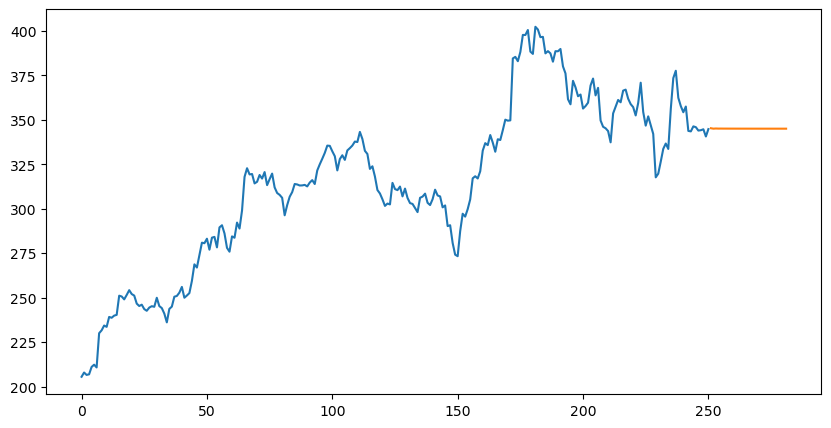

In [100]:
# stats model and arima
from statsmodels.tsa.arima.model import ARIMA
p, d, q = 2, 1, 2

model = ARIMA(df['Close'], order=(p, d, q))
model = model.fit()
print(model.summary())

# predict next 30 days
forecast = model.predict(len(df["Close"]), len(df['Close'])+30)
print(forecast)

# plot forecast
plt.figure(figsize=(10, 5))
plt.plot(df['Close'], label='Actual')
plt.plot(forecast, label='Forecast')

In [105]:
# let's ran the SARIMA
import statsmodels.api as sm
import warnings

p, d, q =  2, 1, 2
model = sm.tsa.statespace.SARIMAX(df['Close'], 
                                 order=(p, d, q), 
                                 seasonal_order=(p, d, q, 12))

warnings.filterwarnings('ignore')
model_fit = model.fit()
print(model_fit.summary())


                                     SARIMAX Results                                      
Dep. Variable:                              Close   No. Observations:                  251
Model:             SARIMAX(2, 1, 2)x(2, 1, 2, 12)   Log Likelihood                -793.531
Date:                            Sat, 22 Aug 2026   AIC                           1605.061
Time:                                    16:08:02   BIC                           1636.312
Sample:                                         0   HQIC                          1617.656
                                            - 251                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1096      0.035      3.113      0.002       0.041       0.179
ar.L2         -0.9238      0.043   

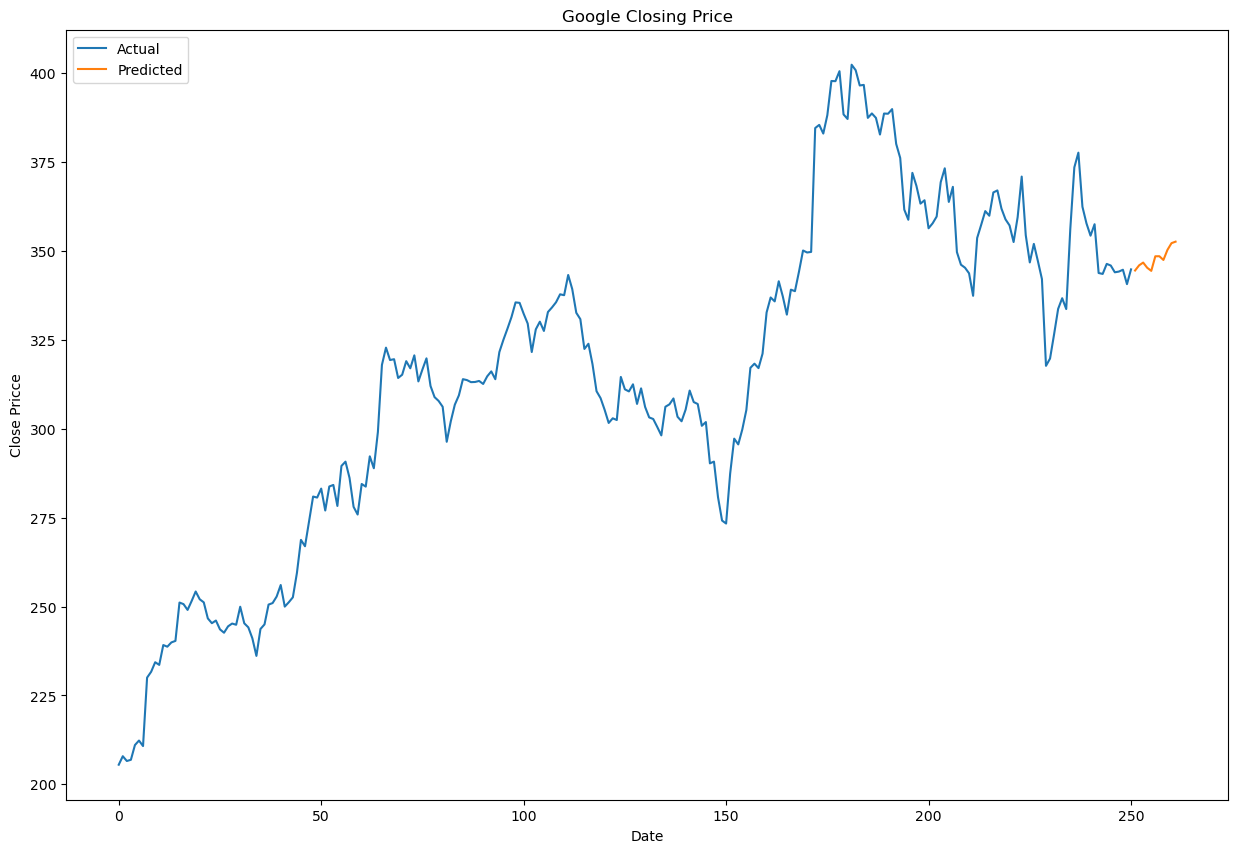

In [114]:
# prediction 
predict = model_fit.predict(start=len(df['Close']), end=len(df['Close'])+10)

# plot the predictions
plt.figure(figsize=(15, 10))
plt.plot(df['Close'], label='Actual')
plt.plot(predict, label='Predicted')
plt.xlabel("Date")
plt.ylabel("Close Pricce")
plt.title("Google Closing Price")
# change the legent location
plt.legend(loc='upper left')
plt.show()

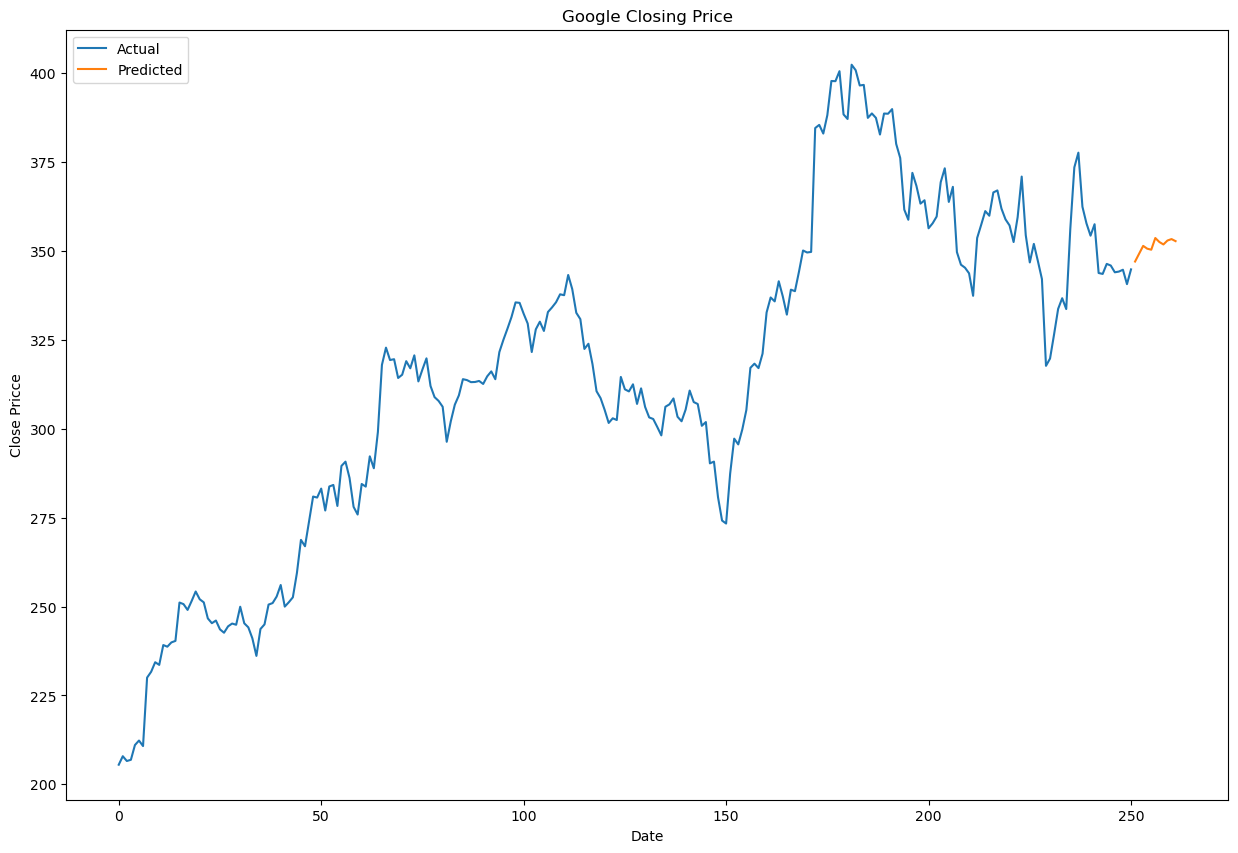

In [117]:
# let's update the p , d, q values
import statsmodels.api as sm
import warnings

p, d, q =  3, 1, 2
model = sm.tsa.statespace.SARIMAX(df['Close'], 
                                 order=(p, d, q), 
                                 seasonal_order=(p, d, q, 12))

warnings.filterwarnings('ignore')
model_fit = model.fit()

# prediction 
predict = model_fit.predict(start=len(df['Close']), end=len(df['Close'])+10)

# plot the predictions
plt.figure(figsize=(15, 10))
plt.plot(df['Close'], label='Actual')
plt.plot(predict, label='Predicted')
plt.xlabel("Date")
plt.ylabel("Close Pricce")
plt.title("Google Closing Price")
# change the legent location
plt.legend(loc='upper left')
plt.show()

# hyper parameter tuning

Best SARIMA(0, 1, 1)x(0, 1, 1, 12)12 model - AIC:1509.754218121327


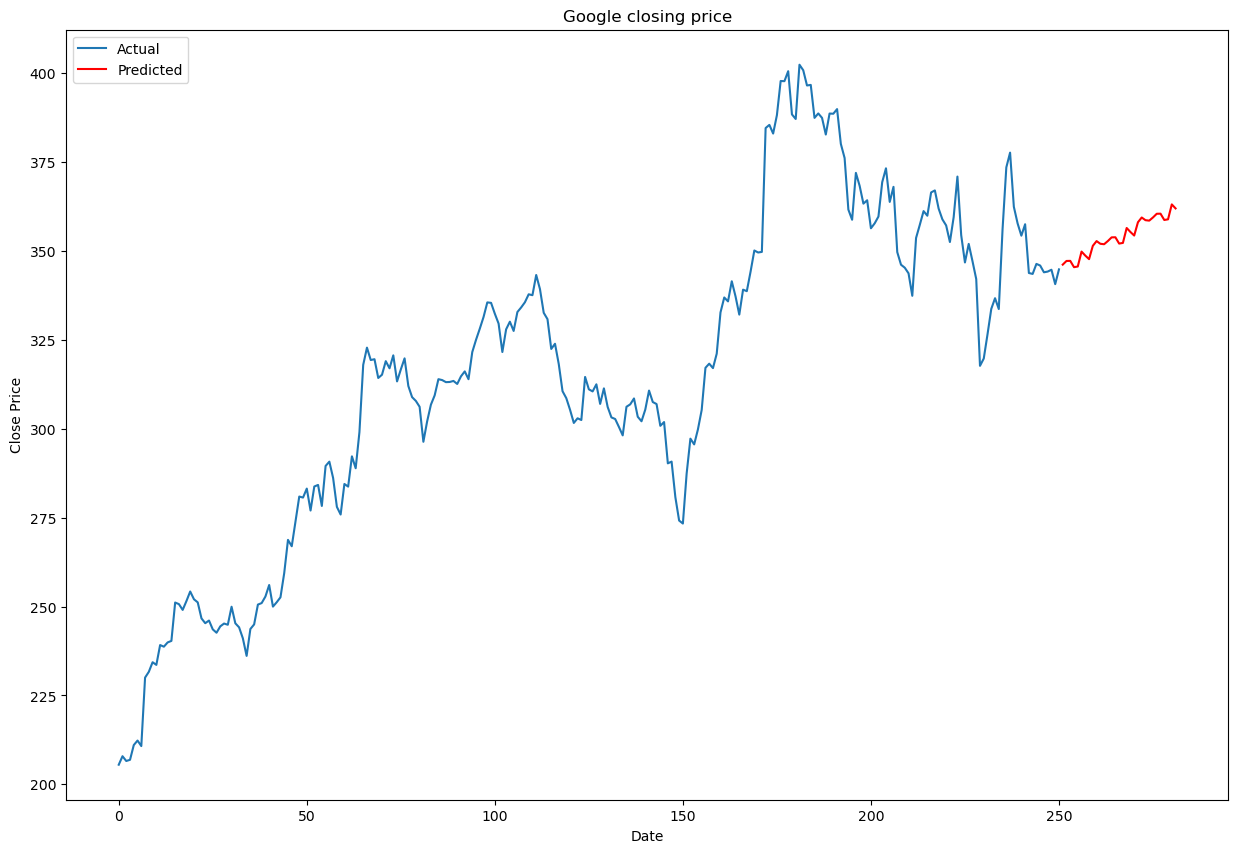

In [118]:
# hyper parameter tuning 
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
import numpy as np
import itertools

# Assume you have a DataFrame 'df' with your time series data in a column named 'value'
# Assume that the seasonal period of your time series data is 12 (e.g., monthly data)

# Define the p, d, q parameters to take any value between 0 and 2
p = d = q = range(0, 2)

# Generate all different combinations of p, d and q triplets
pdq = list(itertools.product(p, d, q))

# Generate all different combinations of seasonal p, d, q and m quadruplets
seasonal_pdq = [(x[0], x[1], x[2], 12) for x in list(itertools.product(p, d, q))]

best_aic = np.inf
best_pdq = None
best_seasonal_pdq = None
temp_model = None

for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            temp_model = SARIMAX(df['Close'],
                                 order = param,
                                 seasonal_order = param_seasonal,
                                 enforce_stationarity=False,
                                 enforce_invertibility=False)
            results = temp_model.fit()

            # print("SARIMA{}x{}12 - AIC:{}".format(param, param_seasonal, results.aic))
            if results.aic < best_aic:
                best_aic = results.aic
                best_pdq = param
                best_seasonal_pdq = param_seasonal
        except:
            continue

print("Best SARIMA{}x{}12 model - AIC:{}".format(best_pdq, best_seasonal_pdq, best_aic))

# predict next 30 days
model = SARIMAX(df['Close'],
                order = best_pdq,
                seasonal_order = best_seasonal_pdq,
                enforce_stationarity=False,
                enforce_invertibility=False)

model = model.fit()
predictions = model.predict(len(df['Close']), len(df['Close'])+30)

# plot the predictions
plt.figure(figsize=(15, 10))
plt.plot(df["Close"], label='Actual')
plt.plot(predictions, color='red', label='Predicted')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.title('Google closing price')
# change legend location
plt.legend(loc='upper left')
plt.show()

In [119]:
print(model.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              Close   No. Observations:                  251
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 12)   Log Likelihood                -751.877
Date:                            Sat, 22 Aug 2026   AIC                           1509.754
Time:                                    16:30:54   BIC                           1519.989
Sample:                                         0   HQIC                          1513.886
                                            - 251                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.0952      0.073      1.299      0.194      -0.048       0.239
ma.S.L12      -1.0000    593.065   